# Notebook 3: Hailo Parsing & INT8 Quantization

This notebook converts the ONNX model into Hailo's format and quantizes it to INT8 using
Post-Training Quantization (PTQ).

**Pipeline:**
1. Parse ONNX -> Hailo Archive (HAR) with `ClientRunner`
2. Apply ALLS model script (normalization + NMS configuration for 11 document classes)
3. Prepare a dataset-aware calibration subset (diverse train images from Notebook 1)
4. Run INT8 quantization via `runner.optimize()`
5. Compare FP32 vs quantized inference quality

**Key concepts:**
- **ALLS script:** Hailo's model configuration language for normalization, NMS, and layer control
- **Calibration:** Uses a representative subset of training images to compute activation statistics
  for mapping FP32 values to INT8. Diversity matters more than raw volume.
- **NMS replacement:** We strip PyTorch NMS and use Hailo's hardware-accelerated NMS instead

## 1. Setup & Imports

In [1]:
import os
import time
import numpy as np
from pathlib import Path
from PIL import Image

import matplotlib
# Compatibility shim for newer Matplotlib with older matplotlib-inline builds.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__
import matplotlib.pyplot as plt

from hailo_sdk_client import ClientRunner, InferenceContext

WORKSPACE = Path("/home/appuser/Hailo-Training")
MODELS_DIR = WORKSPACE / "models"
DATASET_DIR = WORKSPACE / "datasets" / "doclaynet"

print("Hailo SDK client imported successfully.")

E0000 00:00:1774501451.160031    4055 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774501451.250360    4055 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


[info] First time Hailo Dataflow Compiler is being used. Checking system requirements... (this might take a few seconds)
[Warning] CUDNN version should be 9 or higher, found ..
Component                                Requirement                    Found                               
==========  ==========       ==========  ==========                                                         
OS                                       Ubuntu               Ubuntu                                        Required
Release     20.04                        22.04                                       Required               
Package     python3-tk                   V                    Required                                      
Package     graphviz                     V                    Required                                      
Package     libgraphviz-dev              V                    Required                                      
Package     python3.10-dev               V          

## 2. Configuration

In [2]:
# Hailo target hardware
HW_ARCH = "hailo8l"

# Model settings
NET_NAME = "doclaynet_yolo26n"
ONNX_PATH = str(MODELS_DIR / "best_simplified.onnx")
INPUT_SHAPE = (1, 3, 640, 640)  # NCHW

# Output paths
HAR_PATH = str(MODELS_DIR / f"{NET_NAME}.har")
QUANTIZED_HAR_PATH = str(MODELS_DIR / f"{NET_NAME}_quantized.har")

# Calibration settings (auto-scale with train split size from Notebook 1)
TARGET_SIZE = (640, 640)
CALIB_MIN = 64
CALIB_MAX = 1024
CALIB_FRACTION = 0.25

train_img_dir = DATASET_DIR / "images" / "train"
assert train_img_dir.exists(), f"Train image directory not found: {train_img_dir}. Run Notebook 1 first."
train_image_files = sorted([
    f for f in os.listdir(train_img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))
])
num_train_images = len(train_image_files)
assert num_train_images > 0, f"No training images found in {train_img_dir}. Run Notebook 1 first."

# Pick a representative calibration size for PTQ while capping runtime/memory.
CALIB_SIZE = int(num_train_images * CALIB_FRACTION)
CALIB_SIZE = max(CALIB_MIN, min(CALIB_SIZE, CALIB_MAX, num_train_images))

# DocLayNet classes
NUM_CLASSES = 11
CLASS_NAMES = [
    "Caption", "Footnote", "Formula", "List-item", "Page-footer",
    "Page-header", "Picture", "Section-header", "Table", "Text", "Title"
]

# Verify ONNX model exists
assert os.path.exists(ONNX_PATH), f"ONNX model not found: {ONNX_PATH}. Run Notebook 2 first."
print(f"Hardware target: {HW_ARCH}")
print(f"ONNX model: {ONNX_PATH}")
print(f"Train images found: {num_train_images}")
print(f"Calibration images: {CALIB_SIZE} (min={CALIB_MIN}, max={CALIB_MAX}, fraction={CALIB_FRACTION:.0%})")

Hardware target: hailo8l
ONNX model: /home/appuser/Hailo-Training/models/best_simplified.onnx
Train images found: 3000
Calibration images: 750 (min=64, max=1024, fraction=25%)


## 3. Prepare Calibration Dataset

Load a diverse set of images from the training set prepared in Notebook 1.
These are used purely for activation statistics — no labels are needed.

The calibration dataset must be a numpy array of shape `(N, H, W, 3)` in float32.

In [3]:
def load_calibration_images(img_dir, target_size, max_images):
    """Load and preprocess images for Hailo calibration."""
    img_files = sorted([
        os.path.join(img_dir, f) for f in os.listdir(img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    # Take evenly spaced samples for diversity
    if len(img_files) > max_images:
        step = len(img_files) / max_images
        img_files = [img_files[int(i * step)] for i in range(max_images)]
    else:
        img_files = img_files[:max_images]

    images = []
    for fpath in img_files:
        img = Image.open(fpath).convert("RGB")
        img = img.resize(target_size, Image.BILINEAR)
        images.append(np.array(img).astype(np.float32))

    calib_data = np.stack(images, axis=0)  # (N, H, W, 3)
    return calib_data


calib_img_dir = str(DATASET_DIR / "images" / "train")
calib_dataset = load_calibration_images(calib_img_dir, TARGET_SIZE, CALIB_SIZE)

print(f"Calibration dataset shape: {calib_dataset.shape}")
print(f"Value range: [{calib_dataset.min():.0f}, {calib_dataset.max():.0f}]")
print(f"Dtype: {calib_dataset.dtype}")
print(f"Memory: {calib_dataset.nbytes / (1024**2):.1f} MB")

Calibration dataset shape: (750, 640, 640, 3)
Value range: [0, 255]
Dtype: float32
Memory: 3515.6 MB


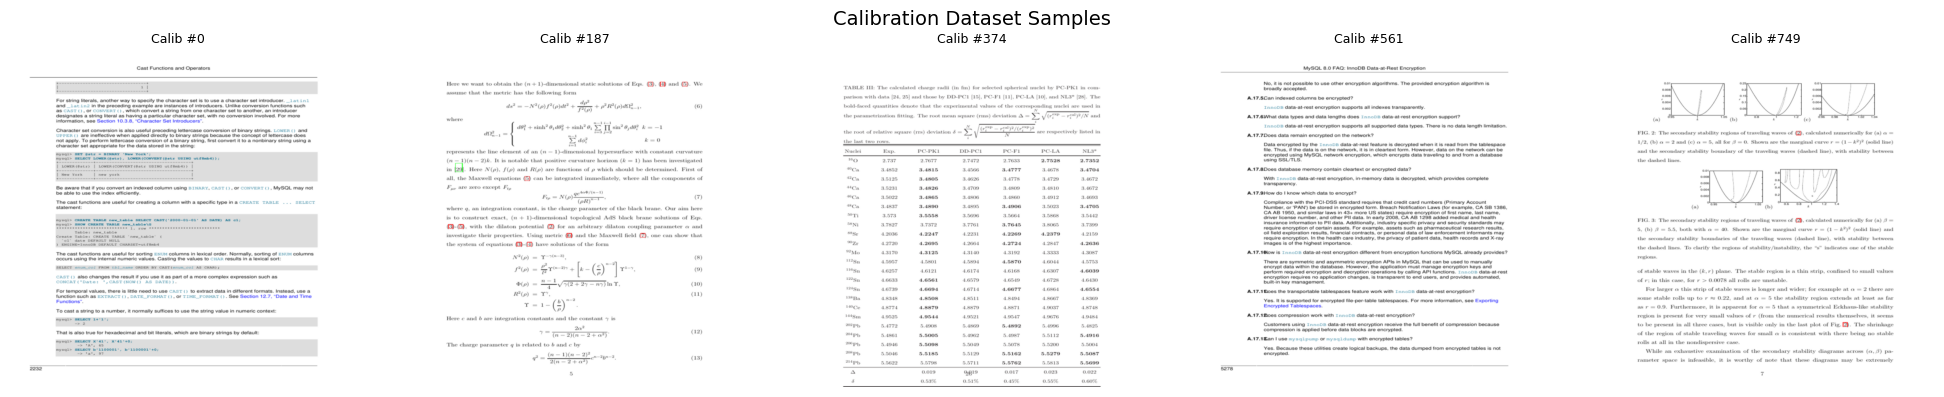

In [4]:
# Show a few calibration images
num_preview = min(5, len(calib_dataset))
fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
if num_preview == 1:
    axes = [axes]

indices = np.linspace(0, len(calib_dataset) - 1, num_preview, dtype=int)
for ax, idx in zip(axes, indices):
    ax.imshow(calib_dataset[idx].astype(np.uint8))
    ax.set_title(f"Calib #{idx}", fontsize=9)
    ax.axis("off")

plt.suptitle("Calibration Dataset Samples", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Parse ONNX to Hailo Format

The `ClientRunner` translates the ONNX graph into Hailo's internal HN + NPZ representation
and saves it as a HAR (Hailo Archive) file.

For YOLO-style exports, parser recommendations may ask to cut parsing before unsupported
post-processing ops (for example, `TopK`/`GatherElements`) and re-add NMS through
`nms_postprocess` in the model script.

In [20]:
# Initialize ClientRunner
runner = ClientRunner(hw_arch=HW_ARCH)

# Parse the ONNX model
print("Parsing ONNX model...")
t0 = time.time()

try:
    hn, npz = runner.translate_onnx_model(
        ONNX_PATH,
        NET_NAME,
        # Use all raw one2one detection head conv outputs (3 scales x {bbox,cls}).
        end_node_names=[
            "/model.23/one2one_cv2.0/one2one_cv2.0.2/Conv",
            "/model.23/one2one_cv3.0/one2one_cv3.0.2/Conv",
            "/model.23/one2one_cv2.1/one2one_cv2.1.2/Conv",
            "/model.23/one2one_cv3.1/one2one_cv3.1.2/Conv",
            "/model.23/one2one_cv2.2/one2one_cv2.2.2/Conv",
            "/model.23/one2one_cv3.2/one2one_cv3.2.2/Conv",
        ],
        # If your export uses a different input tensor name, set net_input_shapes accordingly.
        # net_input_shapes={"images": [1, 3, 640, 640]},
    )
except Exception as e:
    err = str(e)
    if "Please try to parse the model again, using these end node names:" in err:
        print("Parser provided an updated end-node recommendation.")
        print("Copy the suggested node name(s) into end_node_names and re-run this cell.")
    raise

parse_time = time.time() - t0
print(f"Parsing completed in {parse_time:.1f}s")

# Save initial HAR
runner.save_har(HAR_PATH)
har_size_mb = os.path.getsize(HAR_PATH) / (1024 * 1024)
print(f"Initial HAR saved: {HAR_PATH} ({har_size_mb:.1f} MB)")

Parsing ONNX model...
[info] Translation started on ONNX model doclaynet_yolo26n
[info] Restored ONNX model doclaynet_yolo26n (completion time: 00:00:00.03)
[info] Extracted ONNXRuntime meta-data for Hailo model (completion time: 00:00:00.26)
[info] NMS structure of yolov6 (or equivalent architecture) was detected.
[info] In order to use HailoRT post-processing capabilities, these end node names should be used: /model.23/one2one_cv2.0/one2one_cv2.0.2/Conv /model.23/one2one_cv3.0/one2one_cv3.0.2/Conv /model.23/one2one_cv2.1/one2one_cv2.1.2/Conv /model.23/one2one_cv3.1/one2one_cv3.1.2/Conv /model.23/one2one_cv2.2/one2one_cv2.2.2/Conv /model.23/one2one_cv3.2/one2one_cv3.2.2/Conv.
[info] Start nodes mapped from original model: 'images': 'doclaynet_yolo26n/input_layer1'.
[info] End nodes mapped from original model: '/model.23/one2one_cv2.0/one2one_cv2.0.2/Conv', '/model.23/one2one_cv3.0/one2one_cv3.0.2/Conv', '/model.23/one2one_cv2.1/one2one_cv2.1.2/Conv', '/model.23/one2one_cv3.1/one2one_c

## 5. Apply ALLS Model Script

The ALLS (Accelerated Layer Library Script) configures:
- **Normalization:** Divides pixel values by 255 so inference input can be uint8 [0-255]
- **NMS postprocess:** Replaces PyTorch NMS with Hailo's post-processing path

For this YOLO26n export, Hailo SDK identifies the detection structure as YOLOv6-equivalent
for NMS configuration, so we use `meta_arch=yolov6`.

In [27]:
# Define the ALLS model script
# NOTE: For this YOLO26 one2one export on DFC 3.33.1, automatic NMS layer mapping
# can fail during optimize(). We keep normalization for quantization stability and
# add/validate postprocess in a later stage if needed.
alls_script = f"""
normalization1 = normalization([0.0, 0.0, 0.0], [255.0, 255.0, 255.0])
"""

print("ALLS Model Script:")
print(alls_script)

# Load the script into the runner
runner.load_model_script(alls_script)
print("Model script loaded successfully.")

ALLS Model Script:

normalization1 = normalization([0.0, 0.0, 0.0], [255.0, 255.0, 255.0])

[info] Loading model script commands to doclaynet_yolo26n from string


Model script loaded successfully.


## 6. INT8 Quantization (PTQ)

This is the core step: the optimizer analyzes the calibration data to determine optimal
quantization parameters (scale and zero-point) for each layer, converting FP32 weights
and activations to INT8.

This step may take several minutes depending on model size and calibration set.

In [28]:
print(f"Starting INT8 quantization with {len(calib_dataset)} calibration images...")
print("This may take several minutes.\n")

t0 = time.time()
runner.optimize(calib_dataset)
quant_time = time.time() - t0

print(f"\nQuantization completed in {quant_time:.1f}s ({quant_time/60:.1f} min)")

Starting INT8 quantization with 750 calibration images...
This may take several minutes.

[info] Found model with 3 input channels, using real RGB images for calibration instead of sampling random data.
[info] Starting Model Optimization
[warning] Reducing optimization level to 0 (the accuracy won't be optimized and compression won't be used) because there's less data than the recommended amount (1024), and there's no available GPU
[warning] Running model optimization with zero level of optimization is not recommended for production use and might lead to suboptimal accuracy results
[info] Model received quantization params from the hn
[info] MatmulDecompose skipped
[info] Starting Mixed Precision
[info] Model Optimization Algorithm Mixed Precision is done (completion time is 00:00:01.03)
[info] LayerNorm Decomposition skipped
[info] Starting Statistics Collector
[info] Using dataset with 64 entries for calibration


Calibration: 100%|██████████| 64/64 [01:02<00:00,  1.03entries/s]


[info] Model Optimization Algorithm Statistics Collector is done (completion time is 00:01:04.50)
[info] Starting Fix zp_comp Encoding
[info] Model Optimization Algorithm Fix zp_comp Encoding is done (completion time is 00:00:00.00)
[info] Starting Matmul Equalization
[info] Model Optimization Algorithm Matmul Equalization is done (completion time is 00:00:00.09)
[info] Starting MatmulDecomposeFix
[info] Model Optimization Algorithm MatmulDecomposeFix is done (completion time is 00:00:00.00)
[info] activation fitting started for doclaynet_yolo26n/reduce_sum_softmax1/act_op
[info] activation fitting started for doclaynet_yolo26n/reduce_sum_softmax2/act_op
[info] Finetune encoding skipped
[info] Bias Correction skipped
[info] Adaround skipped
[info] Quantization-Aware Fine-Tuning skipped
[info] Layer Noise Analysis skipped
[info] Model Optimization is done

Quantization completed in 192.4s (3.2 min)


In [29]:
# Save quantized HAR
runner.save_har(QUANTIZED_HAR_PATH)
quant_har_size_mb = os.path.getsize(QUANTIZED_HAR_PATH) / (1024 * 1024)

print(f"Quantized HAR saved: {QUANTIZED_HAR_PATH}")
print(f"Quantized HAR size: {quant_har_size_mb:.1f} MB")
print(f"\nSize comparison:")
print(f"  Initial HAR:    {har_size_mb:.1f} MB")
print(f"  Quantized HAR:  {quant_har_size_mb:.1f} MB")

[info] Saved HAR to: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har
Quantized HAR saved: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har
Quantized HAR size: 53.6 MB

Size comparison:
  Initial HAR:    9.7 MB
  Quantized HAR:  53.6 MB


## 7. Quantization Quality Check

Compare inference outputs between FP32 and INT8 quantized contexts to assess
accuracy degradation from quantization.

In [30]:
# Load a few test images for comparison
val_img_dir = DATASET_DIR / "images" / "validation"
test_files = sorted(os.listdir(val_img_dir))[:5]

test_images = []
for fname in test_files:
    img = Image.open(val_img_dir / fname).convert("RGB").resize(TARGET_SIZE)
    test_images.append(np.array(img).astype(np.float32))

test_batch = np.stack(test_images)  # (N, 640, 640, 3)
print(f"Test batch shape: {test_batch.shape}")

Test batch shape: (5, 640, 640, 3)


In [32]:
# Run inference in different contexts
print("Running FP32 inference...")
with runner.infer_context(InferenceContext.SDK_FP_OPTIMIZED) as ctx:
    fp32_outputs = runner.infer(ctx, test_batch)

print("Running quantized (INT8) inference...")
with runner.infer_context(InferenceContext.SDK_QUANTIZED) as ctx:
    int8_outputs = runner.infer(ctx, test_batch)

def collect_tensor_leaves(obj, prefix="out"):
    """Recursively collect numeric tensor leaves from nested dict/list/tuple outputs."""
    leaves = []
    if isinstance(obj, dict):
        for key in sorted(obj.keys(), key=str):
            leaves.extend(collect_tensor_leaves(obj[key], f"{prefix}.{key}"))
    elif isinstance(obj, (list, tuple)):
        for i, item in enumerate(obj):
            leaves.extend(collect_tensor_leaves(item, f"{prefix}[{i}]"))
    else:
        try:
            arr = np.asarray(obj)
            # Keep only numeric arrays/scalars
            if np.issubdtype(arr.dtype, np.number):
                leaves.append((prefix, arr))
        except Exception:
            pass
    return leaves

fp_leaves = collect_tensor_leaves(fp32_outputs, "fp")
q_leaves = collect_tensor_leaves(int8_outputs, "int8")

print(f"\nCollected FP32 tensor leaves: {len(fp_leaves)}")
print(f"Collected INT8 tensor leaves: {len(q_leaves)}")

if len(fp_leaves) == 0 or len(q_leaves) == 0:
    print("No numeric tensor leaves were found for comparison.")
else:
    pair_count = min(len(fp_leaves), len(q_leaves))
    print(f"Comparing {pair_count} matched leaf pairs (by traversal order).")

    compared = 0
    skipped = 0

    for i in range(pair_count):
        fp_name, fp_arr = fp_leaves[i]
        q_name, q_arr = q_leaves[i]

        if fp_arr.shape != q_arr.shape:
            skipped += 1
            print(f"\n  Skipping pair {i}: shape mismatch {fp_arr.shape} vs {q_arr.shape}")
            print(f"    FP path: {fp_name}")
            print(f"    INT8 path: {q_name}")
            continue

        fp_vec = fp_arr.astype(np.float64).ravel()
        q_vec = q_arr.astype(np.float64).ravel()

        mae = np.mean(np.abs(fp_vec - q_vec))
        rmse = np.sqrt(np.mean((fp_vec - q_vec) ** 2))
        cosine = np.dot(fp_vec, q_vec) / (np.linalg.norm(fp_vec) * np.linalg.norm(q_vec) + 1e-8)

        compared += 1
        print(f"\n  Leaf pair {i}:")
        print(f"    FP path: {fp_name}")
        print(f"    INT8 path: {q_name}")
        print(f"    Shape: {fp_arr.shape}")
        print(f"    MAE:   {mae:.6f}")
        print(f"    RMSE:  {rmse:.6f}")
        print(f"    Cosine Similarity: {cosine:.6f}")

    print(f"\nSummary: compared={compared}, skipped={skipped}")

Running FP32 inference...


Running quantized (INT8) inference...

Collected FP32 tensor leaves: 6
Collected INT8 tensor leaves: 6
Comparing 6 matched leaf pairs (by traversal order).

  Leaf pair 0:
    FP path: fp[0]
    INT8 path: int8[0]
    Shape: (5, 80, 80, 4)
    MAE:   0.930427
    RMSE:  1.763186
    Cosine Similarity: 0.892563

  Leaf pair 1:
    FP path: fp[1]
    INT8 path: int8[1]
    Shape: (5, 80, 80, 11)
    MAE:   1.744943
    RMSE:  2.370424
    Cosine Similarity: 0.991594

  Leaf pair 2:
    FP path: fp[2]
    INT8 path: int8[2]
    Shape: (5, 40, 40, 4)
    MAE:   0.848146
    RMSE:  1.504351
    Cosine Similarity: 0.952659

  Leaf pair 3:
    FP path: fp[3]
    INT8 path: int8[3]
    Shape: (5, 40, 40, 11)
    MAE:   1.889323
    RMSE:  2.950660
    Cosine Similarity: 0.983213

  Leaf pair 4:
    FP path: fp[4]
    INT8 path: int8[4]
    Shape: (5, 20, 20, 4)
    MAE:   1.376773
    RMSE:  2.106559
    Cosine Similarity: 0.957011

  Leaf pair 5:
    FP path: fp[5]
    INT8 path: int8[5]
    

In [33]:
print("=" * 60)
print("QUANTIZATION SUMMARY")
print("=" * 60)
print(f"Hardware target:     {HW_ARCH}")
print(f"Model name:          {NET_NAME}")
print(f"Calibration images:  {CALIB_SIZE}")
print(f"Parse time:          {parse_time:.1f}s")
print(f"Quantization time:   {quant_time:.1f}s")
print(f"Initial HAR:         {har_size_mb:.1f} MB")
print(f"Quantized HAR:       {quant_har_size_mb:.1f} MB")
print(f"\nQuantized model saved to: {QUANTIZED_HAR_PATH}")
print(f"\nNext step: Run 04_Compilation_and_Profiling.ipynb")

QUANTIZATION SUMMARY
Hardware target:     hailo8l
Model name:          doclaynet_yolo26n
Calibration images:  750
Parse time:          3.7s
Quantization time:   192.4s
Initial HAR:         9.7 MB
Quantized HAR:       53.6 MB

Quantized model saved to: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har

Next step: Run 04_Compilation_and_Profiling.ipynb
